In [112]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [113]:
train_df = pd.read_excel('/workspaces/SML/SML /Exp 8/train.xlsx')
train_df


,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,1,1,0,0,0,5849,0,0,360,2,1
1,2,1,1,1,0,4583,1508,128,360,1,0
2,3,1,1,0,1,3000,0,66,360,2,1
3,4,1,1,0,0,2583,2358,120,360,2,1
4,5,1,0,0,0,6000,0,141,360,2,1
...,...,...,...,...,...,...,...,...,...,...,...
432,609,1,1,0,0,3232,1950,108,360,1,1
433,610,0,0,0,0,2900,0,71,360,1,1
434,611,1,1,3,0,4106,0,40,180,1,1
435,612,1,1,1,0,8072,240,253,360,2,1


In [114]:
test_df = pd.read_excel('/workspaces/SML/SML /Exp 8/test.xlsx')
test_df

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area,Loan_Status
0,7,1,1,0,0,2333,1516.0,95,360,2,1
1,8,1,1,3,0,3036,2504.0,158,360,0,0
2,13,1,1,2,0,3073,8106.0,200,360,2,1
3,20,1,1,0,1,2600,3500.0,115,0,2,1
4,22,1,1,1,0,5955,5625.0,315,360,2,1
...,...,...,...,...,...,...,...,...,...,...,...
172,599,1,1,0,1,9963,0.0,180,360,1,1
173,604,1,0,0,0,3676,4301.0,172,360,1,1
174,605,0,1,1,0,12000,0.0,496,360,0,1
175,608,1,1,2,0,3987,1411.0,157,360,1,1


drop loanid column

In [115]:
test_ids = test_df['Loan_ID']
train_df.drop(columns=['Loan_ID'])
test_df.drop(columns=['Loan_ID'])
test_df.drop(columns=['Loan_Status'], inplace=True)


# Replacing NaN values with 0
train_df.fillna(0, inplace=True)
test_df.fillna(0, inplace=True)

,Loan_ID,Gender,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Property_Area
0,7,1,1,0,0,2333,1516.0,95,360,2
1,8,1,1,3,0,3036,2504.0,158,360,0
2,13,1,1,2,0,3073,8106.0,200,360,2
3,20,1,1,0,1,2600,3500.0,115,0,2
4,22,1,1,1,0,5955,5625.0,315,360,2
...,...,...,...,...,...,...,...,...,...,...
172,599,1,1,0,1,9963,0.0,180,360,1
173,604,1,0,0,0,3676,4301.0,172,360,1
174,605,0,1,1,0,12000,0.0,496,360,0
175,608,1,1,2,0,3987,1411.0,157,360,1


In [116]:
x = train_df.drop(columns=['Loan_Status'])
y = train_df['Loan_Status']

x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=42)

In [117]:
print(f"X_train shape: {x_train.shape}")
print(f"X_val shape: {x_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (349, 10)
X_val shape: (88, 10)
y_train shape: (349,)
y_val shape: (88,)


In [118]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_val = sc.transform(x_val)
X_test_final = test_df[x.columns]
X_test_final_sc = sc.transform(X_test_final)

In [119]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf',random_state=42,gamma=0.5)
classifier.fit(x_train,y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [120]:
from sklearn.metrics import classification_report,accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
y_pred = classifier.predict(x_val)
print("Confusion Matrix",confusion_matrix(y_val,y_pred))
print("Accuracy Score",accuracy_score(y_val,y_pred))
print("F1-score",f1_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

Confusion Matrix [[ 1 25]
 [ 1 61]]
Accuracy Score 0.7045454545454546
F1-score 0.8243243243243243
              precision    recall  f1-score   support

           0       0.50      0.04      0.07        26
           1       0.71      0.98      0.82        62

    accuracy                           0.70        88
   macro avg       0.60      0.51      0.45        88
weighted avg       0.65      0.70      0.60        88



FINAL PREDICTION TEST DATSET

In [121]:

test_predictions = classifier.predict(X_test_final_sc)
submission = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': test_predictions
})
print("\nFirst 5 Predictions for Test Set:")
print(submission.head())




First 5 Predictions for Test Set:
   Loan_ID  Loan_Status
0        7            1
1        8            1
2       13            1
3       20            1
4       22            1


In [122]:
import matplotlib.pyplot as plt

BALANCED WEIGHTS

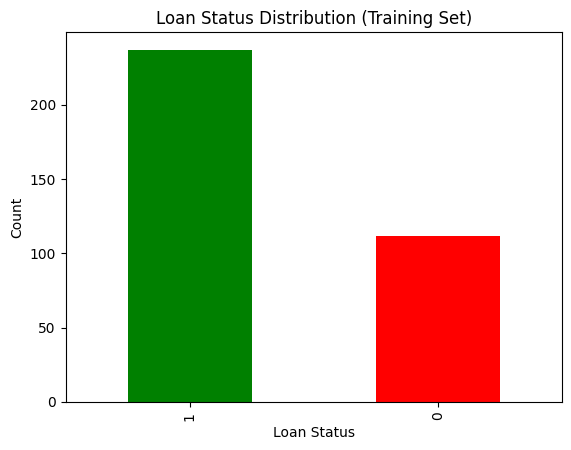

In [123]:
y_train.value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Loan Status Distribution (Training Set)')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [124]:
classifier_balanced = SVC(kernel='rbf', random_state=420, gamma=0.5, class_weight='balanced')
classifier_balanced.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [125]:
y_pred_balanced = classifier_balanced.predict(x_val)
print("Balanced Model Evaluation")
print("Accuracy Score:", accuracy_score(y_val, y_pred_balanced))
print("\nClassification Report:\n", classification_report(y_val, y_pred_balanced))

Balanced Model Evaluation
Accuracy Score: 0.5681818181818182

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.31      0.30        26
           1       0.70      0.68      0.69        62

    accuracy                           0.57        88
   macro avg       0.49      0.49      0.49        88
weighted avg       0.58      0.57      0.57        88



In [126]:
def feature_engineering(df):
    df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['Total_Income_Log'] = np.log1p(df['Total_Income'])
    df['loan_amount_log'] = np.log1p(df['LoanAmount'])
    df['EMI'] = df['LoanAmount'] / (df['Loan_Amount_Term'] + 1)
    df['balance_income'] = df['Total_Income'] - (df['EMI'] * 100)
    df['income_loan_ratio'] = df['Total_Income'] / (df['LoanAmount'] + 1)
    return df


X_fe = feature_engineering(train_df.drop(columns=['Loan_Status'])).select_dtypes(include=[np.number])
test_fe = feature_engineering(test_df).select_dtypes(include=[np.number])


X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(X_fe, y, test_size=0.2, random_state=42)


# Scaling engineered features
sc_fe = StandardScaler()
X_train_fe = sc_fe.fit_transform(X_train_fe)
X_val_fe = sc_fe.transform(X_val_fe)
test_fe_scaled = sc_fe.transform(test_fe)

FEATURE ENGINEERING

In [127]:
classifier_fe = SVC(kernel='rbf', random_state=42, class_weight='balanced')
classifier_fe.fit(X_train_fe, y_train_fe)
y_pred_fe = classifier_fe.predict(X_val_fe)
print("Engineered Features Model Accuracy:", accuracy_score(y_val_fe, y_pred_fe))

Engineered Features Model Accuracy: 0.5227272727272727


In [128]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from matplotlib.colors import ListedColormap
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, StratifiedKFold
pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', StandardScaler()),
                     ('svm', SVC(class_weight='balanced', probability=True))])


param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [1, 0.1, 0.01, 0.001, 'scale'],
    'svm__kernel': ['rbf', 'poly', 'linear']
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(pipeline, param_grid, refit=True, verbose=2, cv=cv)
grid.fit(X_train_fe, y_train_fe)


print("\nBest Parameters found by Grid Search:", grid.best_params_)


best_grid_pred = grid.predict(X_val_fe)
print("\nBest Model (Grid Search) Validation Evaluation:")
print("Accuracy Score:", accuracy_score(y_val_fe, best_grid_pred))
print("\nClassification Report:\n", classification_report(y_val_fe, best_grid_pred))



Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END ..........svm__C=0.1, svm__gamma=1, svm__kernel=rbf; total time=   0.0s
[CV] END .........svm__C=0.1, svm__gamma=1, svm__kernel=poly; total time=   0.1s
[CV] END .........svm__C=0.1, svm__gamma=1, svm__kernel=poly; total time=   0.0s
[CV] END .........svm__C=0.1, svm__gamma=1, svm__kernel=poly; total time=   0.0s
[CV] END .........svm__C=0.1, svm__gamma=1, svm__kernel=poly; total time=   0.0s
[CV] END .........svm__C=0.1, svm__gamma=1, svm__kernel=poly; total time=   0.0s
[CV] END .......svm__C=0.1, svm__gamma=1, svm__kernel=linear; total time=   0.0s
[CV] END .......svm__C=0.1, svm__gamma=1, svm__

/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [130]:
final_test_predictions = grid.predict(test_fe_scaled)
submission_final = pd.DataFrame({
    'Loan_ID': test_ids,
    'Loan_Status': final_test_predictions
})
print("\nFirst 5 Predictions for Test Set (Grid Search):")
print(submission_final.head())




First 5 Predictions for Test Set (Grid Search):
   Loan_ID  Loan_Status
0        7            1
1        8            1
2       13            1
3       20            1
4       22            1


In [132]:


# 1. Feature Engineering (Same logic, added copy safety)
def feature_engineering(df):
    df = df.copy()
    # Filling internal NaNs just in case they weren't handled globally
    df = df.fillna(0) 
    
    df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
    df['Total_Income_Log'] = np.log1p(df['Total_Income'])
    df['loan_amount_log'] = np.log1p(df['LoanAmount'])
    df['EMI'] = df['LoanAmount'] / (df['Loan_Amount_Term'] + 1)
    df['balance_income'] = df['Total_Income'] - (df['EMI'] * 100)
    df['income_loan_ratio'] = df['Total_Income'] / (df['LoanAmount'] + 1)
    
    return df.select_dtypes(include=[np.number])

# 2. Data Preparation - THE CRITICAL PART
# Ensure the target has no NaNs and align X accordingly
clean_df = train_df.dropna(subset=['Loan_Status']) # Drop rows where target is missing
X = feature_engineering(clean_df.drop(columns=['Loan_Status']))
y = clean_df['Loan_Status'].map({'Y': 1, 'N': 0}).astype(int)

# Split the data
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling
sc_fe = StandardScaler()
# We fit on all features but we will only use the first two for the plot
X_train_scaled = sc_fe.fit_transform(X_train_fe)
X_val_scaled = sc_fe.transform(X_val_fe)

# 4. Visualization Setup
# Only take the first two columns of the SCALED arrays
X_set, y_set = X_val_scaled[:, :2], y_val_fe.values

classifier_vis = SVC(kernel='rbf', random_state=42)
# Fit using only the first two columns of training data
classifier_vis.fit(X_train_scaled[:, :2], y_train_fe)

# 5. Meshgrid with slightly larger step for performance
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.05),
    np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.05)
)

# 6. Prediction
Z = classifier_vis.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

# 7. Plotting
plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, Z, alpha = 0.75, cmap = ListedColormap(('red', 'green')))

# Scatter plot
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = [ListedColormap(('red', 'green'))(i)], 
                label = 'Approved (1)' if j == 1 else 'Rejected (0)',
                edgecolors='black')

plt.title('SVM RBF Decision Boundary')
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.legend()
plt.show()

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer.Replace or remove non-finite values or cast to an integer typethat supports these values (e.g. 'Int64')